In [1]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gpt2 import Config, Model

In [2]:
@dataclass
class TrainingConfig:
    #device: torch.device = torch.device("cuda")
    device: torch.device = torch.device("cpu")

    shard_dir: str = "data"

    # Training steps and data processing
    #n_steps: int = 4768
    n_steps: int = 10
    #n_tokens_per_step: int = 524288
    n_tokens_per_step: int = 4096  
    #batch_size: int = 64
    batch_size: int = 2
    #sequence_len: int = 1024
    sequence_len: int = 128
    nvocab: int = 50304

    # Optimisation and learning rate scheduling
    weight_decay: float = 0.1
    max_lr: float = 6e-4
    min_lr: float = 6e-5
    n_warmup_steps: int = 715
    n_decay_steps: int = 4053
    betas: tuple[float, float] = (0.9, 0.95)
    clip_norm: float = 1.0

In [3]:
#Task 3.02: Initialising the model

import torch
import torch.nn as nn

def configure_m(config: TrainingConfig) -> Model:
    # Create model configuration
    model_config = Config(
        n_vocab=Config.n_vocab
    )

    # Create model
    model = Model(model_config)

    # ---------------------------------------------------
    # Weight initialization function
    # ---------------------------------------------------
    def init_weights(module):

        # Linear layers
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        # Embedding layers
        elif isinstance(module, nn.Embedding):

            # Token embeddings
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # Apply initialization recursively
    model.apply(init_weights)

    # ---------------------------------------------------
    # Position embeddings (smaller std = 0.01)
    # ---------------------------------------------------
    if hasattr(model, "position_embedding"):
        nn.init.normal_(
            model.position_embedding.weight,
            mean=0.0,
            std=0.01
        )

    # ---------------------------------------------------
    # Weight tying
    # ---------------------------------------------------
    if hasattr(model, "lm_head") and hasattr(model, "token_embedding"):
        model.lm_head.weight = model.token_embedding.weight

    return model


In [ ]:
#Task 3.03 step 3: Update your model initialization to include the scaled residual initialisation
import math
import torch
import torch.nn as nn

def configure_model(config: TrainingConfig) -> Model:
    #model_config = Config(n_vocab=config.n_vocab)
    model_config = Config(n_vocab=config.nvocab)
    model = Model(model_config)

    n_residual_layers = 2 * model_config.n_layer
    c_proj_std = 0.02 / math.sqrt(n_residual_layers)

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            std = c_proj_std if name.endswith("c_proj") else 0.02
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    if hasattr(model, "wpe"):
        nn.init.normal_(model.wpe.weight, mean=0.0, std=0.01)

    if hasattr(model, "lm_head") and hasattr(model, "wte"):
        model.lm_head.weight = model.wte.weight

    return model

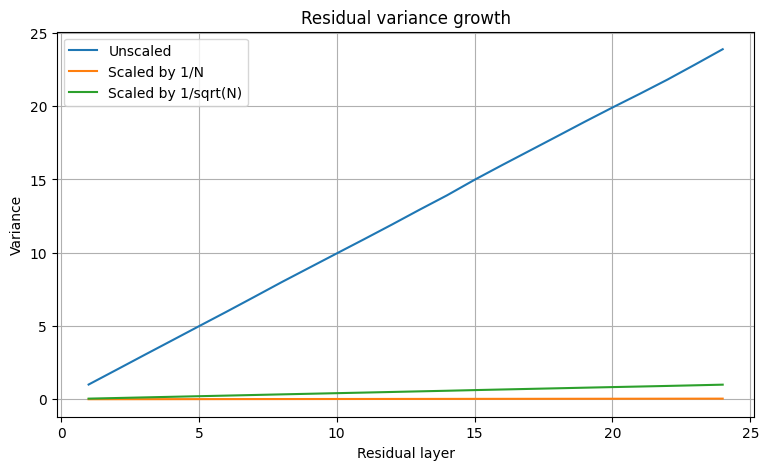

In [4]:
#Task 3.03 step 2:  Stimulate scaled residual concept:
import math
import torch
import matplotlib.pyplot as plt

def simulate_three_cases(N=24, width=100000):
    x_unscaled = torch.zeros(width)
    x_one_over_n = torch.zeros(width)
    x_one_over_sqrt_n = torch.zeros(width)

    vars_unscaled = []
    vars_one_over_n = []
    vars_one_over_sqrt_n = []

    k1 = 1 / N
    k2 = 1 / math.sqrt(N)

    for layer in range(1, N + 1):
        residual = torch.randn(width)

        x_unscaled = x_unscaled + residual
        x_one_over_n = x_one_over_n + k1 * residual
        x_one_over_sqrt_n = x_one_over_sqrt_n + k2 * residual

        vars_unscaled.append(torch.var(x_unscaled).item())
        vars_one_over_n.append(torch.var(x_one_over_n).item())
        vars_one_over_sqrt_n.append(torch.var(x_one_over_sqrt_n).item())

    plt.figure(figsize=(9, 5))
    plt.plot(range(1, N + 1), vars_unscaled, label="Unscaled")
    plt.plot(range(1, N + 1), vars_one_over_n, label="Scaled by 1/N")
    plt.plot(range(1, N + 1), vars_one_over_sqrt_n, label="Scaled by 1/sqrt(N)")
    plt.xlabel("Residual layer")
    plt.ylabel("Variance")
    plt.title("Residual variance growth")
    plt.legend()
    plt.grid(True)
    plt.show()

simulate_three_cases()

In [5]:
def shards(shard_dir: str):
    for shard in sorted(os.listdir(shard_dir)):
        yield torch.from_numpy(np.load(os.path.join(shard_dir, shard)).astype(np.int64))

In [6]:
 sum(s.numel() for s in shards(TrainingConfig().shard_dir))

300000000

In [7]:
shard = torch.tensor(range(15), dtype=torch.long)

# Suppose we want to package the tokens in this shard into batches of shape (2, 3).

# Step 1: Segment the shard into overlapping chunks of size 2 * 3 + 1
chunk1 = shard[0:7]
chunk2 = shard[6:13]
excess = shard[12:]

# Step 2: Create batches from all but the last and all but the first token in each chunk
x1, y1 = chunk1[:-1].view(2, 3), chunk1[1:].view(2, 3)
x2, y2 = chunk2[:-1].view(2, 3), chunk2[1:].view(2, 3)

In [8]:
#task 3.04: batching the data
def make_batches(config: TrainingConfig):
    chunk_size = config.batch_size * config.sequence_len + 1
    buffer = torch.empty(0, dtype=torch.long)
    
    for shard in shards(config.shard_dir):
        # Concatenate previous excess with current shard
        buffer = torch.cat([buffer, shard])
        
        # Extract as many complete chunks as possible
        while len(buffer) >= chunk_size:
            chunk = buffer[:chunk_size]
            buffer = buffer[chunk_size - 1:]  # Keep last token for overlap
            
            # Create input/target pair
            x = chunk[:-1].view(config.batch_size, config.sequence_len)
            y = chunk[1:].view(config.batch_size, config.sequence_len)
            
            yield x, y

In [9]:
def configure_optimizer(model: Model, config: TrainingConfig):
    params = [p for p in model.parameters() if p.requires_grad]
    decay_params = [p for p in params if p.dim() >= 2]
    no_decay_params = [p for p in params if p.dim() < 2]
    param_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(
        param_groups,
        lr=config.max_lr,
        betas=config.betas,
        #fused=(config.device.type == "cuda"),
        fused=(config.device.type == "cpu"),
    )

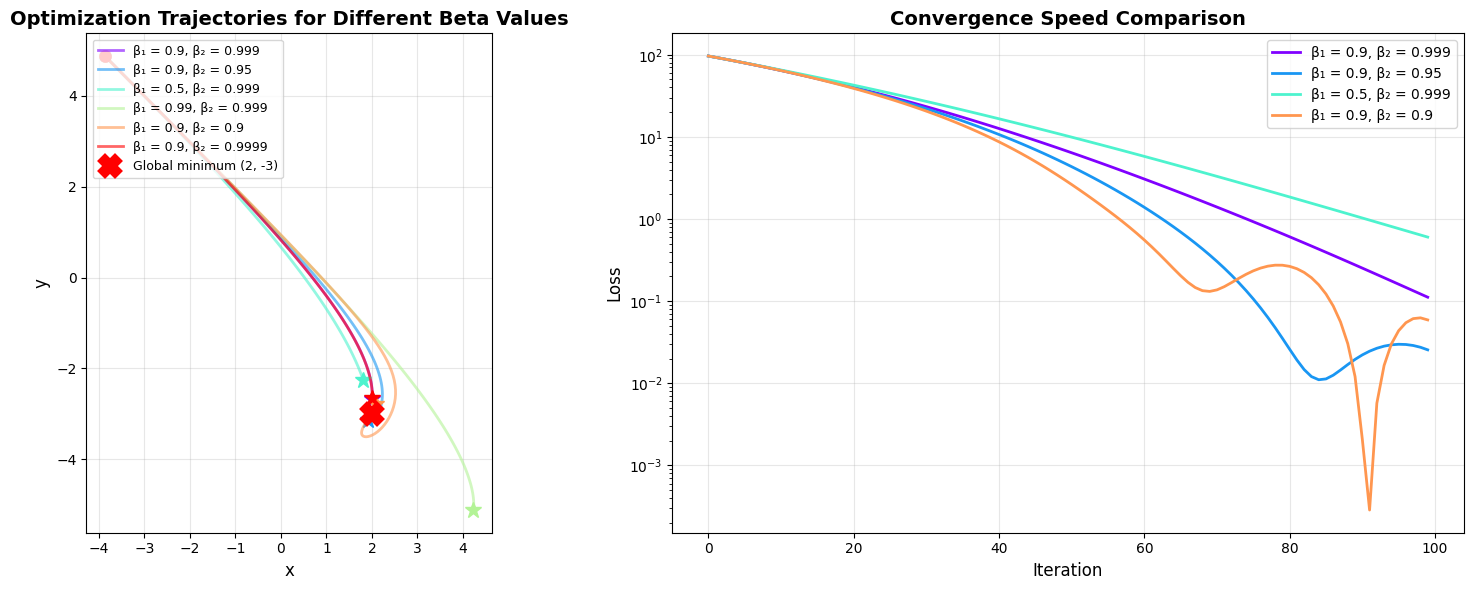

Final Loss Values After 100 Iterations:
------------------------------------------------------------
β₁ = 0.9, β₂ = 0.999           → Loss: 32.102943
β₁ = 0.9, β₂ = 0.95            → Loss: 37.694052
β₁ = 0.5, β₂ = 0.999           → Loss: 27.582912
β₁ = 0.99, β₂ = 0.999          → Loss: 70.768443
β₁ = 0.9, β₂ = 0.9             → Loss: 33.378747
β₁ = 0.9, β₂ = 0.9999          → Loss: 31.981649


In [11]:
#Task 3.05: Exploring the beta parameters
import torch
import matplotlib.pyplot as plt
import numpy as np

def adam_trajectories(betas):
    def loss_function(x, y):
        return (x - 2) ** 2 + (y + 3) ** 2

    for beta1, beta2 in betas:
        x = torch.tensor([-4.0], requires_grad=True)
        y = torch.tensor([5.0], requires_grad=True)
        optimizer = torch.optim.AdamW((x, y), lr=0.125, betas=(beta1, beta2))
        trajectory = []
        for _ in range(100):
            optimizer.zero_grad()
            loss = loss_function(x, y)
            loss.backward()
            optimizer.step()
            trajectory.append((x.item(), y.item()))
        yield trajectory, f"β₁ = {beta1}, β₂ = {beta2}"


# Define different beta configurations to test
beta_configs = [
    (0.9, 0.999),    # PyTorch default
    (0.9, 0.95),     # GPT-2 training config
    (0.5, 0.999),    # Low β₁ (less momentum)
    (0.99, 0.999),   # High β₁ (more momentum)
    (0.9, 0.9),      # Low β₂ (less stable adaptive LR)
    (0.9, 0.9999),   # Very high β₂ (very stable adaptive LR)
]

# Generate trajectories
trajectories = list(adam_trajectories(beta_configs))

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All trajectories in 2D space
colors = plt.cm.rainbow(np.linspace(0, 1, len(trajectories)))

for (trajectory, label), color in zip(trajectories, colors):
    x_vals = [point[0] for point in trajectory]
    y_vals = [point[1] for point in trajectory]
    
    ax1.plot(x_vals, y_vals, '-', color=color, alpha=0.6, linewidth=2, label=label)
    ax1.plot(x_vals[0], y_vals[0], 'o', color=color, markersize=8)  # Start point
    ax1.plot(x_vals[-1], y_vals[-1], '*', color=color, markersize=12)  # End point

# Mark the global minimum
ax1.plot(2, -3, 'rX', markersize=15, markeredgewidth=3, label='Global minimum (2, -3)')

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Optimization Trajectories for Different Beta Values', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: Loss over iterations (comparing key configurations)
key_configs = [0, 1, 2, 4]  # Default, GPT-2, Low β₁, Low β₂
for idx in key_configs:
    trajectory, label = trajectories[idx]
    losses = [(x - 2)**2 + (y + 3)**2 for x, y in trajectory]
    ax2.plot(losses, linewidth=2, label=label, color=colors[idx])

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Convergence Speed Comparison', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('beta_parameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final losses
print("Final Loss Values After 100 Iterations:")
print("-" * 60)
for trajectory, label in trajectories:
    final_x, final_y = trajectory[-1]
    final_loss = (final_x - 2)**2 + (final_y - 3)**2
    print(f"{label:30s} → Loss: {final_loss:.6f}")

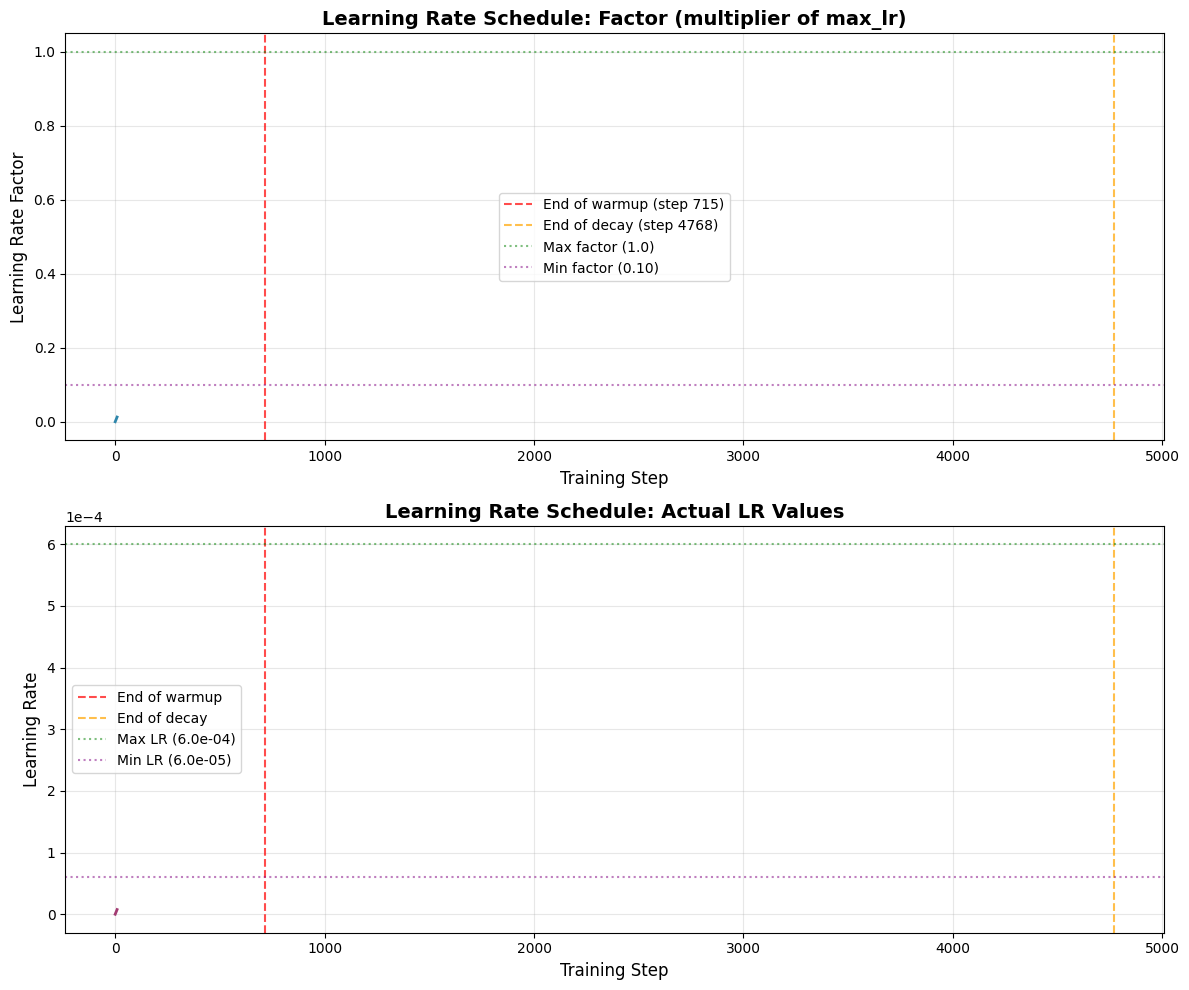

Learning Rate Schedule Key Points:
Step 0:    LR = 0.000000e+00 (start of warmup)
Step 715:  LR = 6.000000e-04 (end of warmup)
Step 2741: LR = 3.301046e-04 (mid-decay)
Step 4768: LR = 6.000000e-05 (end of decay)
Step 9: LR = 7.552448e-06 (final)


In [12]:
#task 3.06 Implementing the cosine decay
import math
import torch
import matplotlib.pyplot as plt

def get_lr_factor(step: int, config: TrainingConfig) -> float:
    """
    Returns the learning rate factor for a given step.
    The actual LR will be: lr = config.max_lr * get_lr_factor(step)
    
    Returns 1.0 at the end of warmup, then decays via cosine to min_lr/max_lr ratio.
    """
    
    # Phase 1: Linear warmup
    if step < config.n_warmup_steps:
        # Linear increase from 0 to 1
        return step / config.n_warmup_steps
    
    # Phase 2: Cosine decay
    elif step < config.n_warmup_steps + config.n_decay_steps:
        # Shift step to start decay phase from 0
        decay_step = step - config.n_warmup_steps
        
        # Normalize to [0, 1] range for cosine function
        progress = decay_step / config.n_decay_steps
        
        # Cosine decay formula: 0.5 * (1 + cos(π * progress))
        # This gives 1.0 at progress=0 and 0.0 at progress=1
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
        
        # Scale between min_lr and max_lr
        # At progress=0: factor = 1.0 (max_lr)
        # At progress=1: factor = min_lr/max_lr
        min_factor = config.min_lr / config.max_lr
        return min_factor + (1.0 - min_factor) * cosine_decay
    
    # Phase 3: After decay ends, stay at minimum
    else:
        return config.min_lr / config.max_lr


# Visualization code
def visualize_lr_schedule(config: TrainingConfig):
    """Visualize the learning rate schedule"""
    steps = list(range(config.n_steps))
    lr_factors = [get_lr_factor(step, config) for step in steps]
    actual_lrs = [config.max_lr * factor for factor in lr_factors]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Learning rate factor
    ax1.plot(steps, lr_factors, linewidth=2, color='#2E86AB')
    ax1.axvline(config.n_warmup_steps, color='red', linestyle='--', 
                label=f'End of warmup (step {config.n_warmup_steps})', alpha=0.7)
    ax1.axvline(config.n_warmup_steps + config.n_decay_steps, color='orange', 
                linestyle='--', label=f'End of decay (step {config.n_warmup_steps + config.n_decay_steps})', 
                alpha=0.7)
    ax1.axhline(1.0, color='green', linestyle=':', label='Max factor (1.0)', alpha=0.5)
    ax1.axhline(config.min_lr / config.max_lr, color='purple', linestyle=':', 
                label=f'Min factor ({config.min_lr / config.max_lr:.2f})', alpha=0.5)
    
    ax1.set_xlabel('Training Step', fontsize=12)
    ax1.set_ylabel('Learning Rate Factor', fontsize=12)
    ax1.set_title('Learning Rate Schedule: Factor (multiplier of max_lr)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Actual learning rate
    ax2.plot(steps, actual_lrs, linewidth=2, color='#A23B72')
    ax2.axvline(config.n_warmup_steps, color='red', linestyle='--', 
                label=f'End of warmup', alpha=0.7)
    ax2.axvline(config.n_warmup_steps + config.n_decay_steps, color='orange', 
                linestyle='--', label=f'End of decay', alpha=0.7)
    ax2.axhline(config.max_lr, color='green', linestyle=':', 
                label=f'Max LR ({config.max_lr:.1e})', alpha=0.5)
    ax2.axhline(config.min_lr, color='purple', linestyle=':', 
                label=f'Min LR ({config.min_lr:.1e})', alpha=0.5)
    
    ax2.set_xlabel('Training Step', fontsize=12)
    ax2.set_ylabel('Learning Rate', fontsize=12)
    ax2.set_title('Learning Rate Schedule: Actual LR Values', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    plt.savefig('lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print key values
    print("Learning Rate Schedule Key Points:")
    print("=" * 60)
    print(f"Step 0:    LR = {config.max_lr * get_lr_factor(0, config):.6e} (start of warmup)")
    print(f"Step {config.n_warmup_steps}:  LR = {config.max_lr * get_lr_factor(config.n_warmup_steps, config):.6e} (end of warmup)")
    print(f"Step {config.n_warmup_steps + config.n_decay_steps//2}: LR = {config.max_lr * get_lr_factor(config.n_warmup_steps + config.n_decay_steps//2, config):.6e} (mid-decay)")
    print(f"Step {config.n_warmup_steps + config.n_decay_steps}: LR = {config.max_lr * get_lr_factor(config.n_warmup_steps + config.n_decay_steps, config):.6e} (end of decay)")
    print(f"Step {config.n_steps - 1}: LR = {config.max_lr * get_lr_factor(config.n_steps - 1, config):.6e} (final)")


# Test with the training configuration
from dataclasses import dataclass

#@dataclass
#class TrainingConfig:
#    n_steps: int = 4768
#    n_warmup_steps: int = 715
#    n_decay_steps: int = 4053
#    max_lr: float = 6e-4
#    min_lr: float = 6e-5

config = TrainingConfig()
visualize_lr_schedule(config)

In [ ]:
"""
def train(config: TrainingConfig):
    model = configure_model(config)
    model = model.to(config.device)

    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda step: get_lr_factor(step, config),
    )

    n_micro_steps = config.ntokensperstep // (
        config.batchsize * config.sequencelen
    )

    for step in range(config.nsteps):
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0

        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)

            logits = model(x)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                y.view(-1)
            )

            loss.backward()
            running_loss += loss.item()

        nn.utils.clip_grad_norm_(model.parameters(), config.clipnorm)
        optimizer.step()

        lr = scheduler.get_last_lr()[0]
        scheduler.step()

        print(f"step {step:4d} | loss: {running_loss:.4f} | lr: {lr:.4e}")
    """

In [ ]:
#train(TrainingConfig())
#commented here because there out of memory error here


In [13]:
#Task 3.08: Fixing the gradient accumulation
def accumulation_example():
    # Set up a simple model and simulate some input
    model = nn.Linear(3, 2)
    x = torch.randn(2, 3)
    y = torch.randint(0, 2, (2,))

    # Compute the gradient on the complete input
    model.zero_grad()
    output = model(x)
    loss = F.cross_entropy(output, y)
    loss.backward()
    print(model.weight.grad)

    # Compute the gradient using micro-batches (flawed)
    model.zero_grad()
    for i in range(2):
        output = model(x[i : i + 1])
        loss = F.cross_entropy(output, y[i : i + 1])
        loss.backward()
    print(model.weight.grad)


accumulation_example()

tensor([[-0.2643,  1.0088,  0.2875],
        [ 0.2643, -1.0088, -0.2875]])
tensor([[-0.5287,  2.0177,  0.5749],
        [ 0.5287, -2.0177, -0.5749]])


In [16]:
#Task 3.09: Profiling the training loop
def train(config: TrainingConfig):
    model = configure_model(config)
    model = model.to(config.device)
    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda step: get_lr_factor(step, config),
    )
    n_micro_steps = config.n_tokens_per_step // (
        config.batch_size * config.sequence_len
    )
    
    for step in range(config.n_steps):
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        
        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            
            # FIX: Scale loss before backward
            (loss / n_micro_steps).backward()
            
            running_loss += loss.item()
        
        nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
        optimizer.step()
        lr = scheduler.get_last_lr()[0]
        scheduler.step()
        print(f"step {step:4d} loss {running_loss / n_micro_steps:.4f} lr {lr:.4e}")

In [17]:
# 1. Configure model with scaled residual initialization
import math

def configure_model(config: TrainingConfig) -> Model:
    model_config = Config(n_vocab=config.nvocab)
    model = Model(model_config)
    
    n_residual_layers = 2 * model_config.n_layer
    c_proj_std = 0.02 / math.sqrt(n_residual_layers)
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            std = c_proj_std if name.endswith("c_proj") else 0.02
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    if hasattr(model, "wpe"):
        nn.init.normal_(model.wpe.weight, mean=0.0, std=0.01)
    
    if hasattr(model, "lm_head") and hasattr(model, "wte"):
        model.lm_head.weight = model.wte.weight
    
    return model


# 2. Learning rate schedule
def get_lr_factor(step: int, config: TrainingConfig) -> float:
    if step < config.n_warmup_steps:
        return step / config.n_warmup_steps
    elif step < config.n_warmup_steps + config.n_decay_steps:
        decay_step = step - config.n_warmup_steps
        progress = decay_step / config.n_decay_steps
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
        min_factor = config.min_lr / config.max_lr
        return min_factor + (1.0 - min_factor) * cosine_decay
    else:
        return config.min_lr / config.max_lr


# 3. Fixed training loop
def train(config: TrainingConfig):
    model = configure_model(config)
    model = model.to(config.device)
    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda step: get_lr_factor(step, config),
    )
    n_micro_steps = config.n_tokens_per_step // (
        config.batch_size * config.sequence_len
    )
    
    for step in range(config.n_steps):
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        
        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            (loss / n_micro_steps).backward()  # FIX: Scale the loss
            running_loss += loss.item()
        
        nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
        optimizer.step()
        lr = scheduler.get_last_lr()[0]
        scheduler.step()
        print(f"step {step:4d} loss {running_loss / n_micro_steps:.4f} lr {lr:.4e}")

In [ ]:
train(TrainingConfig())

step    0 loss 10.9546 lr 0.0000e+00
step    1 loss 10.9218 lr 8.3916e-07
step    2 loss 10.9123 lr 1.6783e-06
step    3 loss 10.8368 lr 2.5175e-06
step    4 loss 10.7490 lr 3.3566e-06


In [ ]:
#Task 3.10: Exploring floating-point representations
def train(config: TrainingConfig):
    # ── Step 1: Enable TF32 for matrix multiplications ──────────────────────
    # Changes internal matmul precision from fp32 to tf32 on NVIDIA Ampere+ GPUs.
    # 'high' means: use tf32 when available, fall back to fp32 otherwise.
    torch.set_float32_matmul_precision("high")

    model = configure_model(config)
    model = model.to(config.device)
    batches = make_batches(config)
    optimizer = configure_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda lr: get_lr_factor(lr, config),
    )
    n_micro_steps = config.n_tokens_per_step // (
        config.batch_size * config.sequence_len
    )

    for step in range(config.n_steps):
        t0 = time.time()       # ── profiling timer start

        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        tokens_this_step = 0

        for micro_step in range(n_micro_steps):
            x, y = next(batches)
            x, y = x.to(config.device), y.to(config.device)

            # ── Step 2: Use bf16 for forward pass and loss ───────────────────
            # autocast automatically casts eligible ops (linear layers,
            # attention matmuls, cross_entropy) to bf16 for speed.
            # Gradient accumulation and optimizer step remain in fp32.
            with torch.autocast(device_type=config.device.type, dtype=torch.bfloat16):
                logits = model(x)
                loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))

            # Divide loss by n_micro_steps to correct gradient accumulation scaling
            (loss / n_micro_steps).backward()
            running_loss += loss.item() / n_micro_steps
            tokens_this_step += x.numel()

        nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
        optimizer.step()
        lr = scheduler.get_last_lr()[0]
        scheduler.step()

        # ── Step 3: Profiling 
        torch.cuda.synchronize()                  # wait for all GPU ops to finish
        t1 = time.time()
        elapsed = t1 - t0
        tok_per_sec = tokens_this_step / elapsed
        print(
            f"step {step:4d} | loss: {running_loss:.4f} | lr: {lr:.4e} "
            f"| tok/s: {tok_per_sec:,.0f} | step time: {elapsed*1000:.1f}ms"
        )

In [ ]:
train(TrainingConfig())

In [ ]:
#Task 3.11: Exploring just-in-time compilation
model = torch.compile(model)


In [ ]:
#Task 3.12: Evaluating the pretrained model
pretrained = Model(Config(n_vocab=50304))
pretrained.load_state_dict(torch.load("gpt-2-fineweb-edu.pt"))
pretrained.lm_head.weight = pretrained.wte.weight



In [ ]:
import json
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
device = TrainingConfig().device

with open("hellaswag-mini.jsonl") as f:
    n_correct = 0
    n_total = 0
    for line in f:
        sample = json.loads(line)
        prefix = tokenizer.encode(sample["ctx"])
        ending_scores = []
        for i, ending in enumerate(sample["endings"]):
            suffix = tokenizer.encode(" " + ending)
            context = torch.tensor([prefix + suffix], dtype=torch.long, device=device)
            with torch.no_grad():
                logits = pretrained(context)
            ending_score = torch.nn.functional.cross_entropy(
                logits[0, -len(suffix) - 1 : -1], context[0, -len(suffix) :]
            )
            ending_scores.append((ending_score.item(), i))
        predicted = min(ending_scores)[1]
        n_correct += int(predicted == sample["label"])
        n_total += 1
        print(f"Accuracy: {n_correct / n_total:.2%}")